# Segundo Examen Módulo 3: Segmentación de Jugadores FIFA 19
**Diplomado Ciencias de Datos · Generación 33 · FES Acatlán · Abril 2026**

## 1. Objetivo del Proyecto
Identificar segmentos de jugadores con características técnicas y físicas similares,
utilizando únicamente habilidades "puras" (excluyendo métricas compuestas como
Overall o Potential). El resultado servirá como base para la construcción de
equipos ficticios balanceados tácticamente.

## 2. Datos de Entrada
- **`FIFA19-DS.csv`**: Más de 17,000 registros de jugadores, 76 columnas con atributos de juego.
- **`FIFA19-MD.csv`**: Diccionario de variables que define cada columna.


In [19]:
import os
os.makedirs("images", exist_ok=True)
print("Carpeta images/ lista.")


Carpeta images/ lista.


In [20]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn

from sklearn import set_config
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# ── Reproducibilidad ────────────────────────────────────────────────────────
random_seed = 333
np.random.seed(random_seed)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 15)
set_config(transform_output="pandas")
set_config(display='diagram')
warnings.filterwarnings("ignore")

print("Entorno configurado correctamente.")
print(f"Semilla usada: {random_seed}")


Entorno configurado correctamente.
Semilla usada: 333


In [21]:
def dunn_test(df, val_col, group_col, alpha=0.05, p_adjust='bonferroni'):
    """Test post-hoc de Dunn con corrección de Bonferroni."""
    p_values_df = posthoc_dunn(df, val_col=val_col,
                               group_col=group_col, p_adjust=p_adjust)
    results = []
    for i, group1 in enumerate(p_values_df.columns):
        for j, group2 in enumerate(p_values_df.index):
            if j > i:
                p_value = p_values_df.loc[group2, group1]
                decision = (
                    "✅ Rechazar H0 — Hay diferencias significativas."
                    if p_value < alpha else
                    "❌ No rechazar H0 — No hay diferencias significativas."
                )
                results.append({
                    'Variable': val_col,
                    'Grupo 1' : group1,
                    'Grupo 2' : group2,
                    'p-value' : round(p_value, 4),
                    'Decisión': decision
                })
    return pd.DataFrame(results)


def perfilamiento_clusters(df_perfil, columnas, K_FINAL, alpha=0.05):
    """
    Perfilamiento estadístico siguiendo metodología M3_8_Perfilamiento:
      1. Kruskal-Wallis  — discriminación global por variable
      2. Test de Dunn    — comparaciones par a par (post-hoc, Bonferroni)
      3. Radar Chart normalizado
      4. Tabla de medias top 15 variables
    """
    colores = px.colors.qualitative.Set1

    # ── 1. KRUSKAL-WALLIS ────────────────────────────────────────────────────
    print("=" * 60)
    print("KRUSKAL-WALLIS")
    print("=" * 60)

    l_p = []
    for var in columnas:
        grupos = [df_perfil.loc[df_perfil['Cluster'] == c, var].tolist()
                  for c in sorted(df_perfil['Cluster'].unique())]
        kr = kruskal(*grupos)
        l_p.append((var, kr.statistic, kr.pvalue))

    kw_df = pd.DataFrame(l_p, columns=['Variable', 'H-statistic', 'p-value'])
    kw_df['p-value']     = kw_df['p-value'].map(lambda x: round(x, 6))
    kw_df['H-statistic'] = kw_df['H-statistic'].map(lambda x: round(x, 2))
    kw_df['Decisión']    = kw_df['p-value'].map(
        lambda x: '✅ Rechazar H0: Hay diferencias significativas entre los clusters.'
        if x < alpha else
        '❌ No rechazar H0: No hay diferencias significativas entre los clusters.'
    )
    kw_df = kw_df.sort_values('H-statistic', ascending=False).reset_index(drop=True)

    vars_sig = kw_df.loc[kw_df['p-value'] < alpha, 'Variable'].tolist()
    print(f"Variables significativas (p<{alpha}): {len(vars_sig)} de {len(columnas)}\n")
    display(kw_df)

    # ── 2. TEST DE DUNN ──────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("TEST DE DUNN (Bonferroni) — solo variables significativas en KW")
    print("=" * 60)

    all_dunn = pd.DataFrame()
    for var in vars_sig:
        dunn_resultado = dunn_test(df_perfil, val_col=var,
                                   group_col='Cluster', alpha=alpha)
        all_dunn = pd.concat([all_dunn, dunn_resultado], ignore_index=True)
    display(all_dunn)

    # ── 3. RADAR CHART ───────────────────────────────────────────────────────
    scaler_radar = MinMaxScaler()
    df_radar = pd.DataFrame(
        scaler_radar.fit_transform(df_perfil[columnas]),
        columns=columnas
    )
    df_radar['Cluster'] = df_perfil['Cluster'].values
    medias_radar = df_radar.groupby('Cluster').mean()

    vars_radar = [v for v in [
        'Finishing', 'Dribbling', 'ShortPassing', 'LongPassing',
        'Acceleration', 'Strength', 'Jumping', 'Stamina',
        'Marking', 'StandingTackle', 'Interceptions',
        'Vision', 'Positioning'
    ] if v in columnas]

    fig_radar = go.Figure()
    for i in sorted(medias_radar.index):
        vals = medias_radar.loc[i, vars_radar].values.tolist()
        vals.append(vals[0])
        fig_radar.add_trace(go.Scatterpolar(
            r=vals, theta=vars_radar + [vars_radar[0]],
            fill='toself', name=f'Cluster {i}',
            line_color=colores[i]
        ))
    fig_radar.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        title='Radar Chart — Perfil de Habilidades por Cluster (0–1)',
        height=600
    )
    fig_radar.write_image('images/radar_clusters.png', scale=2)
    fig_radar.show()

    # ── 4. MEDIAS POR CLUSTER ────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("MEDIAS POR CLUSTER — top 15 variables más discriminantes")
    print("=" * 60)
    top15 = kw_df.head(15)['Variable'].tolist()
    display(df_perfil.groupby('Cluster')[columnas].mean().round(1)[top15])

    return kw_df, all_dunn

print("Funciones auxiliares cargadas.")


Funciones auxiliares cargadas.


---
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1. Hallazgos Clave
- Los datos contienen variables para todas las posiciones, incluyendo porteros (`GK`).
- Variables como `Overall`, `Potential` y `Special` son métricas compuestas que no
  deben utilizarse en el clustering — sesgarían hacia calidad, no hacia rol táctico.
- Se observan correlaciones altas entre atributos técnicos, justificando PCA.
- Se excluyen `Height`, `Weight` y `Age` porque no definen posición táctica;
  la dimensión física queda capturada por variables funcionales como `Strength` y `Jumping`.

### 3.2. Variables Seleccionadas (27 variables)

| Grupo | Variables |
|---|---|
| **Técnicas (9)** | Crossing, Finishing, ShortPassing, Volleys, Dribbling, FKAccuracy, LongPassing, BallControl, LongShots |
| **Físicas (9)** | Acceleration, SprintSpeed, Agility, Balance, ShotPower, Jumping, Stamina, Strength, HeadingAccuracy |
| **Mentales/Tácticas (4)** | Reactions, Vision, Positioning, Composure |
| **Defensivas (5)** | Aggression, Interceptions, Marking, StandingTackle, SlidingTackle |


In [22]:
# Carga del dataset
df = pd.read_csv('Datos/FIFA19-DS.csv', encoding='utf-8', low_memory=False)
print(f"Dimensiones: {df.shape}")
print(f"Posiciones únicas: {sorted(df['Position'].dropna().unique())}")
df.head()


Dimensiones: (17140, 76)
Posiciones únicas: ['AM', 'DF', 'DM', 'GK', 'MF', 'ST']


,ID,Age,Overall,Potential,Value,Wage,Special,International Reputation,Weak Foot,Skill Moves,Work Rate,Height,Weight,LS,ST,RS,LW,LF,CF,RF,RW,LAM,CAM,RAM,LM,LCM,CM,RCM,RM,LWB,LDM,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Preferred Foot,Body Type,Position
0,158023,31,94,94,110500000,565000,2202,5,4,4,4,5.70,159,90.0,90.0,90.0,94.0,95.0,95.0,95.0,94.0,95.0,95.0,95.0,93.0,86.0,86.0,86.0,93.0,66.0,63.0,63.0,63.0,66.0,61.0,49.0,49.0,49.0,61.0,84,95,70,90,86,97,93,94,87,96,91,86,91,95,95,85,68,72,59,94,48,22,94,94,75,96,33,28,26,6,11,15,14,8,Left,Lean,ST
1,20801,33,94,94,77000000,405000,2228,5,4,5,6,6.20,183,94.0,94.0,94.0,92.0,93.0,93.0,93.0,92.0,91.0,91.0,91.0,91.0,84.0,84.0,84.0,91.0,68.0,64.0,64.0,64.0,68.0,64.0,56.0,56.0,56.0,64.0,84,94,89,81,87,88,81,76,77,94,89,91,87,96,70,95,95,88,79,93,63,29,95,82,85,95,28,31,23,7,11,15,14,11,Right,Normal,ST
2,190871,26,92,93,118500000,290000,2143,5,5,5,7,5.90,150,87.0,87.0,87.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,92.0,91.0,84.0,84.0,84.0,91.0,68.0,63.0,63.0,63.0,68.0,63.0,50.0,50.0,50.0,63.0,79,87,62,84,84,96,88,87,78,95,94,90,96,94,84,80,61,81,49,82,56,36,89,87,81,94,27,24,33,9,9,15,15,11,Right,Lean,AM
3,192985,27,91,92,102000000,355000,2281,4,5,4,8,5.11,154,85.0,85.0,85.0,90.0,90.0,90.0,90.0,90.0,91.0,91.0,91.0,91.0,90.0,90.0,90.0,91.0,80.0,80.0,80.0,80.0,80.0,76.0,69.0,69.0,69.0,76.0,93,82,55,92,82,86,85,83,91,91,78,76,79,91,77,91,63,90,75,91,76,61,87,94,79,88,68,58,51,15,13,5,10,13,Right,Normal,MF
4,183277,27,91,91,93000000,340000,2142,4,4,4,7,5.80,163,86.0,86.0,86.0,92.0,91.0,91.0,91.0,92.0,92.0,92.0,92.0,92.0,85.0,85.0,85.0,92.0,69.0,66.0,66.0,66.0,69.0,63.0,52.0,52.0,52.0,63.0,81,84,61,89,80,95,83,79,83,94,94,88,95,90,94,82,56,83,66,80,54,41,87,89,86,91,34,27,22,11,12,6,8,8,Right,Normal,ST


### 3.3. Análisis Exploratorio de Datos
Inspección inicial de tipos de datos, valores nulos y estadísticas descriptivas.

In [23]:
print("\nTipos de datos:")
display(df.dtypes)

print("\nValores nulos por columna:")
display(df.isna().sum().sort_values(ascending=False))

print("\nResumen estadístico:")
df.describe().T



Tipos de datos:


ID                 int64
Age                int64
Overall            int64
Potential          int64
Value              int64
                   ...  
GKPositioning      int64
GKReflexes         int64
Preferred Foot    object
Body Type         object
Position          object
Length: 76, dtype: object


Valores nulos por columna:


RAM               1842
CAM               1842
LAM               1842
LM                1842
RW                1842
                  ... 
GKPositioning        0
GKReflexes           0
Preferred Foot       0
Body Type            0
Position             0
Length: 76, dtype: int64


Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
ID,17140.0,2.140494e+05,3.001391e+04,16.0,199934.25,221602.0,236305.0,246620.0
Age,17140.0,2.515012e+01,4.658667e+00,16.0,21.00,25.0,28.0,44.0
Overall,17140.0,6.637194e+01,6.925482e+00,46.0,62.00,66.0,71.0,94.0
Potential,17140.0,7.138687e+01,6.159271e+00,48.0,67.00,71.0,75.0,95.0
Value,17140.0,2.486680e+06,5.731964e+06,0.0,325000.00,700000.0,2100000.0,118500000.0
...,...,...,...,...,...,...,...,...
GKDiving,17140.0,1.639924e+01,1.740806e+01,1.0,8.00,11.0,14.0,90.0
GKHandling,17140.0,1.617987e+01,1.664643e+01,1.0,8.00,11.0,14.0,92.0
GKKicking,17140.0,1.602993e+01,1.624687e+01,1.0,8.00,11.0,14.0,91.0
GKPositioning,17140.0,1.617345e+01,1.675260e+01,1.0,8.00,11.0,14.0,90.0


### 3.4. Selección Final de Variables
Se seleccionaron 27 atributos de habilidad pura, excluyendo métricas compuestas
(Overall/Potential) para evitar sesgos de reputación, y variables biométricas estáticas
(Height/Weight) porque presentan alta colinealidad con Strength y no definen rol táctico.


In [24]:
promedio_por_posicion = df.groupby('Position').mean(numeric_only=True)
print("\nPromedio de atributos por posición (vista previa):")
promedio_por_posicion.head()

columnas = [
    # Técnicas (9)
    'Crossing', 'Finishing', 'ShortPassing', 'Volleys', 'Dribbling',
    'FKAccuracy', 'LongPassing', 'BallControl', 'LongShots',
    # Físicas (9)
    'Acceleration', 'SprintSpeed', 'Agility', 'Balance', 'ShotPower',
    'Jumping', 'Stamina', 'Strength', 'HeadingAccuracy',
    # Mentales/Tácticas (4)
    'Reactions', 'Vision', 'Positioning', 'Composure',
    # Defensivas (5)
    'Aggression', 'Interceptions', 'Marking',
    'StandingTackle', 'SlidingTackle',
]

df = df[columnas]
print(f"\nDimensiones del dataset tras selección de variables: {df.shape}")



Promedio de atributos por posición (vista previa):

Dimensiones del dataset tras selección de variables: (17140, 27)


In [25]:
display(df.sample())


,Crossing,Finishing,ShortPassing,Volleys,Dribbling,FKAccuracy,LongPassing,BallControl,LongShots,Acceleration,SprintSpeed,Agility,Balance,ShotPower,Jumping,Stamina,Strength,HeadingAccuracy,Reactions,Vision,Positioning,Composure,Aggression,Interceptions,Marking,StandingTackle,SlidingTackle
7920,39,60,70,30,62,38,70,64,58,59,55,60,56,42,54,57,79,49,66,62,64,60,72,62,60,60,62


### Visualización de Distribuciones

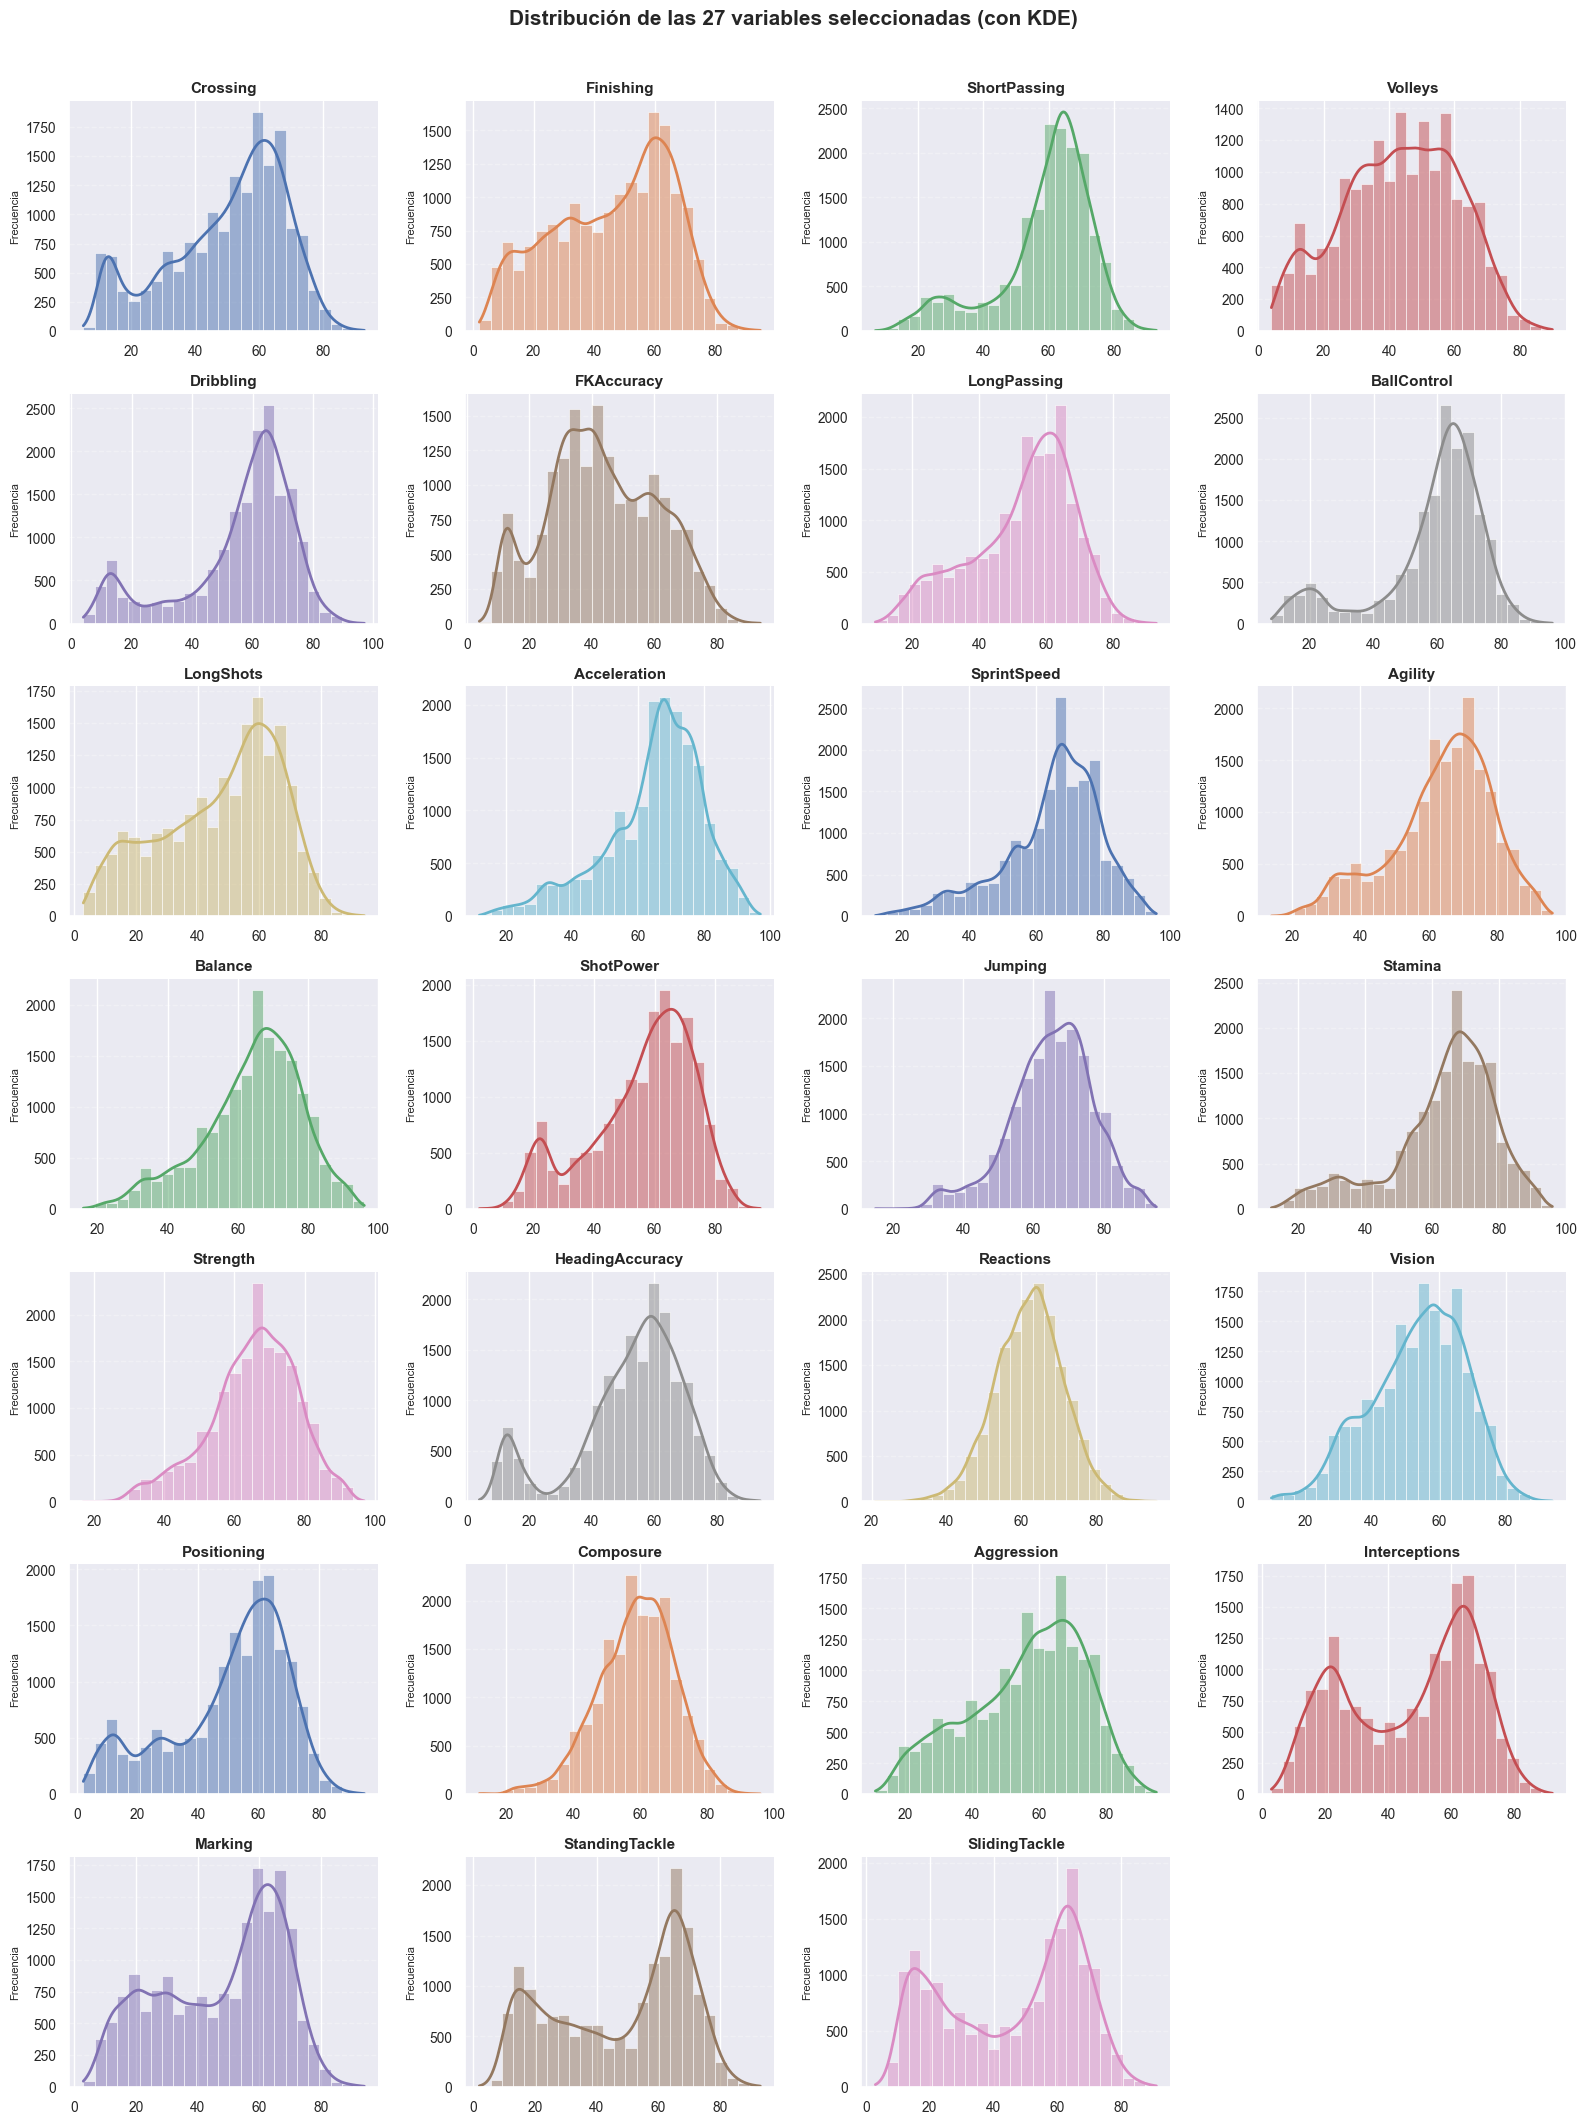

In [26]:
PALETTE = sns.color_palette("deep", n_colors=len(columnas))
n_cols = 4
n_rows = -(-len(columnas) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(columnas):
    sns.histplot(df[col], bins=25, ax=axes[i], kde=True,
                 color=PALETTE[i], edgecolor='white', linewidth=0.4,
                 line_kws={'linewidth': 2})
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia', fontsize=8)
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    axes[i].spines[['top', 'right']].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Distribución de las 27 variables seleccionadas (con KDE)",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("images/01_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()


Los histogramas muestran que variables defensivas como `StandingTackle` o `Marking`
tienen distribuciones bimodales — una población con valores bajos (atacantes/mediocampistas)
y otra con valores altos (defensas). Esto anticipa que el clustering podrá separar
roles tácticos con claridad.


### Matriz de Correlación
La matriz revela alta multicolinealidad entre grupos de variables. Por ejemplo,
`Dribbling`, `Crossing` y `ShortPassing` presentan correlación positiva fuerte.
Las variables defensivas (`Marking`, `StandingTackle`, `SlidingTackle`) forman
un bloque altamente correlacionado. Esta redundancia justifica el uso de PCA.


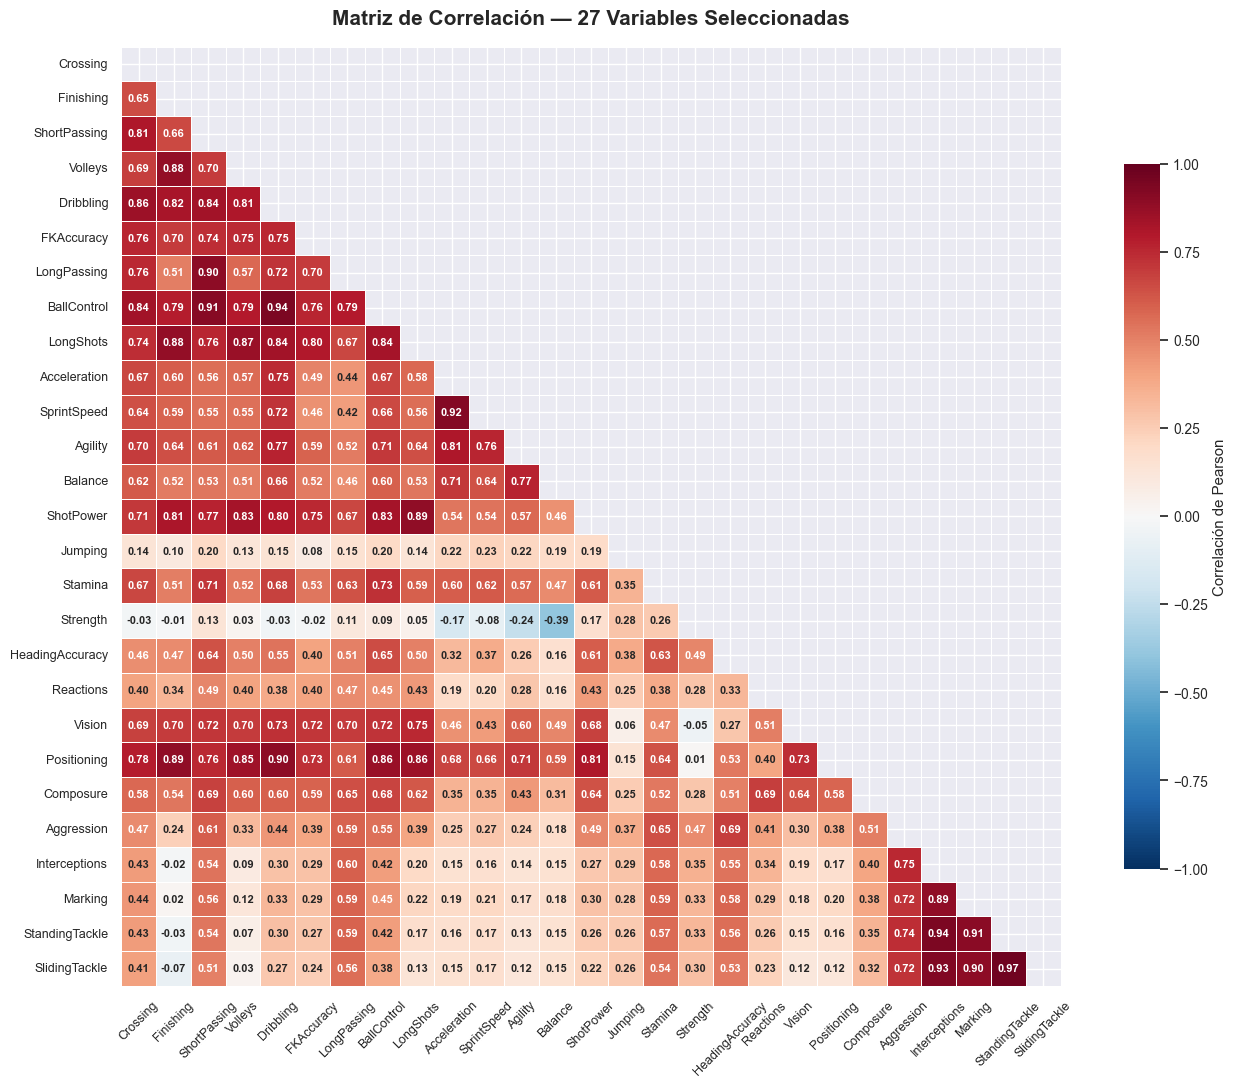

In [27]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
            square=True, annot_kws={"size": 8, "weight": "bold"},
            cbar_kws={"shrink": 0.75, "label": "Correlación de Pearson"}, ax=ax)
ax.set_title("Matriz de Correlación — 27 Variables Seleccionadas",
             fontsize=15, fontweight='bold', pad=16)
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig("images/02_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 5. Reducción de Dimensionalidad: PCA

### 5.1. Justificación
La estandarización (StandardScaler) es crítica porque PCA maximiza la varianza
y es sensible a las escalas. Se usa PCA para manejar la multicolinealidad detectada
y reducir la dimensionalidad conservando la mayor parte de la información.

Introducir variables tan correlacionadas directamente en K-Means distorsionaría
las distancias euclidianas, sesgando el agrupamiento hacia atributos redundantes.

### 5.2. Implementación y Selección de Componentes
Se retienen los componentes que expliquen al menos el **88%** de la varianza acumulada.


In [28]:
# Pipeline: Estandarización + PCA
pipe = make_pipeline(StandardScaler(), PCA())
pipe.fit(df)
pca = pipe.named_steps['pca']

ve = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'variance_ratio': pca.explained_variance_ratio_,
})
ve['cumulative_variance'] = ve['variance_ratio'].cumsum()

# Número de componentes para alcanzar al menos 88% de varianza
n_componentes_88 = (ve['cumulative_variance'] < 0.88).sum() + 1
print(f'Componentes para ≥ 88% de varianza: {n_componentes_88}')

ve_reducida = ve.iloc[:n_componentes_88]
print("\nVarianza explicada por componente:")
ve_reducida


Componentes para ≥ 88% de varianza: 7

Varianza explicada por componente:


,PC,variance_ratio,cumulative_variance
0,PC1,0.524443,0.524443
1,PC2,0.171608,0.696051
2,PC3,0.070750,0.766801
3,PC4,0.049771,0.816572
4,PC5,0.035800,0.852372
5,PC6,0.022340,0.874713
6,PC7,0.013715,0.888428


### Scree Plot (Varianza Explicada por Componente Principal)
Visualización de la varianza explicada acumulada por cada componente principal.
Permite determinar cuántos componentes son necesarios para retener la mayor
parte de la información del dataset.


In [29]:
var_individual = pca.explained_variance_ratio_ * 100
var_acumulada  = np.cumsum(var_individual)
pcs            = list(range(1, len(var_acumulada) + 1))
UMBRAL_PLOT    = 88.0
n_sel          = n_componentes_88

fig = go.Figure()

fig.add_trace(go.Bar(
    x=pcs, y=var_individual,
    name="Varianza individual (%)",
    marker_color="#93c6e0", opacity=0.75,
    hovertemplate="PC%{x}<br>Individual: %{y:.2f}%<extra></extra>",
))

fig.add_trace(go.Scatter(
    x=pcs, y=var_acumulada,
    name="Varianza acumulada (%)",
    mode="lines+markers",
    line=dict(color="#1a6496", width=2.5),
    marker=dict(size=7, color="#1a6496"),
    hovertemplate="PC%{x}<br>Acumulada: %{y:.2f}%<extra></extra>",
))

fig.add_trace(go.Scatter(
    x=[n_sel], y=[var_acumulada[n_sel - 1]],
    name=f"Seleccionado (PC{n_sel} - {var_acumulada[n_sel-1]:.1f}%)",
    mode="markers",
    marker=dict(size=13, color="#e74c3c", symbol="star"),
    hovertemplate=f"PC{n_sel}: {var_acumulada[n_sel-1]:.2f}%<extra></extra>",
))

fig.add_hline(
    y=UMBRAL_PLOT,
    line_dash="dot", line_color="#e67e22", line_width=1.8,
    annotation_text=f"Umbral {UMBRAL_PLOT:.0f}%",
    annotation_position="top right",
    annotation_font=dict(color="#e67e22", size=12),
)

fig.update_layout(
    title=dict(text="Scree Plot — Varianza Explicada por Componente Principal",
               font=dict(size=17), x=0.5, xanchor="center"),
    xaxis=dict(title="Componente Principal", tickmode="linear", dtick=1),
    yaxis=dict(title="Varianza Explicada (%)", range=[0, 103]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    plot_bgcolor="white", bargap=0.25, width=900, height=500,
    hovermode="x unified",
)
fig.write_image("images/03_scree_plot.png", scale=2)
fig.show()


### 5.3. Interpretación de Componentes (Cargas)
Análisis de las cargas factoriales para entender qué habilidades agrupa cada componente.

In [30]:
componentes = pd.DataFrame(
    pca.components_[:n_componentes_88],
    columns=df.columns,
    index=[f'PC{i+1}' for i in range(n_componentes_88)]
)
print("\nCargas de los Componentes Principales:")
componentes



Cargas de los Componentes Principales:


,Crossing,Finishing,ShortPassing,Volleys,Dribbling,FKAccuracy,LongPassing,BallControl,LongShots,Acceleration,SprintSpeed,Agility,Balance,ShotPower,Jumping,Stamina,Strength,HeadingAccuracy,Reactions,Vision,Positioning,Composure,Aggression,Interceptions,Marking,StandingTackle,SlidingTackle
PC1,0.234058,0.206544,0.245783,0.214715,0.245733,0.214322,0.222418,0.253474,0.229429,0.187790,0.184826,0.196695,0.168505,0.228172,0.075114,0.213474,0.035107,0.178130,0.139487,0.201233,0.231467,0.194311,0.168612,0.135663,0.140357,0.132332,0.123657
PC2,-0.034234,-0.221000,0.044456,-0.171086,-0.106787,-0.082437,0.088426,-0.034091,-0.134658,-0.146734,-0.124870,-0.170694,-0.153808,-0.072766,0.125699,0.105291,0.255733,0.177110,0.063926,-0.126050,-0.151742,0.043426,0.277616,0.366890,0.347660,0.371472,0.373011
PC3,-0.103837,0.161975,0.022882,0.178997,-0.049633,0.083509,0.010468,0.012249,0.155257,-0.325351,-0.292898,-0.257955,-0.362434,0.185747,-0.021931,-0.100713,0.394690,0.151663,0.303901,0.142590,0.063225,0.263804,0.056891,-0.115667,-0.138656,-0.159668,-0.188560
PC4,-0.138471,0.086948,-0.134908,0.034636,-0.014671,-0.220272,-0.278660,-0.020362,-0.031504,0.235157,0.293118,0.079106,-0.019740,0.035039,0.556139,0.180920,0.343623,0.290182,-0.043284,-0.254688,0.054126,-0.050577,0.097639,-0.118876,-0.086023,-0.121630,-0.120785
PC5,-0.015370,-0.165678,-0.023661,-0.118892,-0.104320,-0.030601,0.056342,-0.092131,-0.107353,0.026454,-0.013245,0.180627,0.186879,-0.166715,0.430136,-0.049178,-0.120152,-0.298837,0.596466,0.204912,-0.116306,0.337676,-0.046587,0.031700,-0.041530,-0.054079,-0.045625
PC6,-0.053068,0.071343,0.020376,0.121499,-0.041425,0.212402,0.067541,-0.015223,0.139121,-0.302280,-0.371363,-0.061590,0.225605,0.132090,0.597323,-0.149690,-0.292765,0.076090,-0.324231,0.025379,-0.010785,-0.158617,0.040836,0.005739,0.011494,0.019616,0.023472
PC7,0.141784,-0.104343,-0.008499,-0.139207,-0.069003,0.265233,0.224907,-0.125929,0.067275,0.041544,0.063444,0.083661,-0.174158,0.003874,0.160879,0.234827,0.466627,-0.443642,-0.289513,0.336559,-0.073619,-0.228294,-0.020900,-0.009155,-0.080624,-0.034259,-0.044480


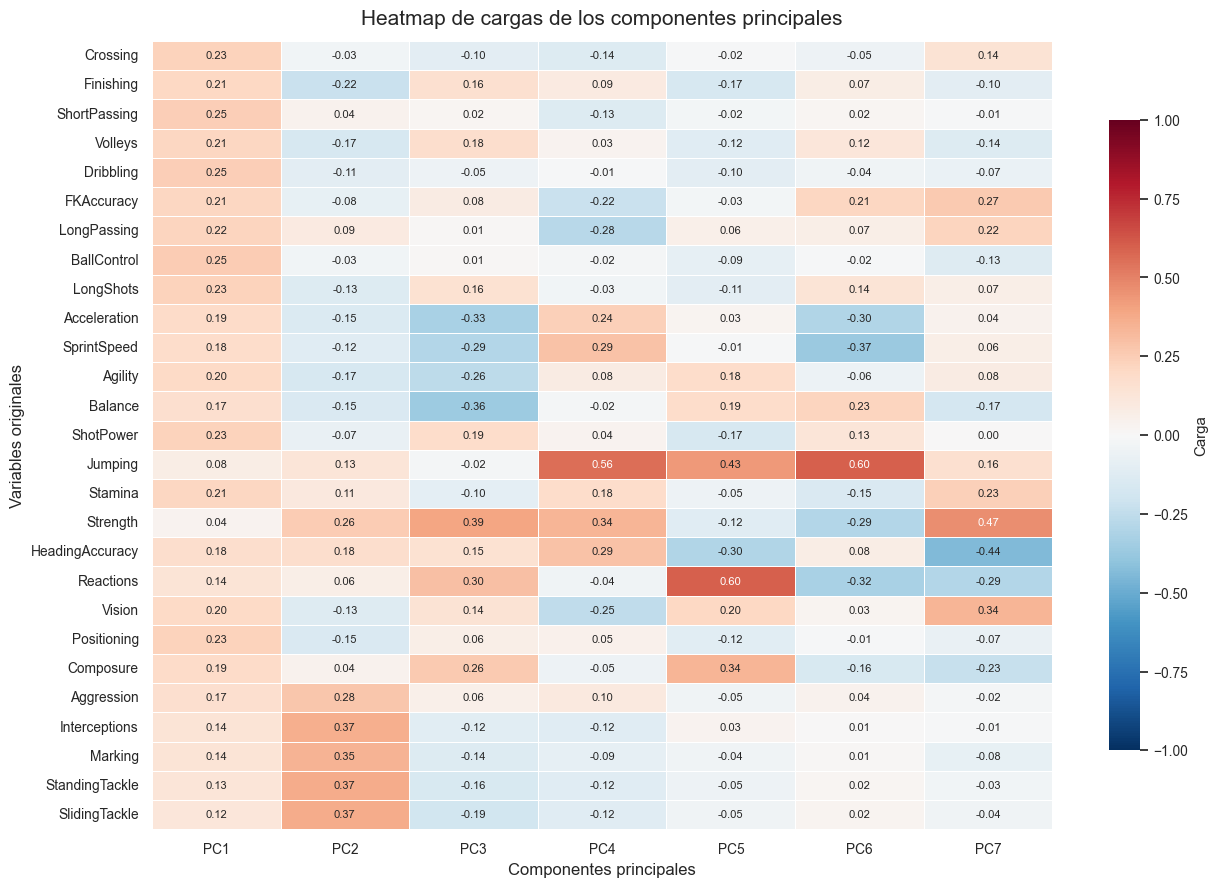

In [31]:
plt.figure(figsize=(13, 9))
sns.set(font_scale=0.9)
ax = sns.heatmap(componentes.T, annot=True, fmt=".2f", cmap="RdBu_r",
                 center=0, vmin=-1, vmax=1, linewidths=.7, linecolor="white",
                 cbar_kws={"shrink": 0.8, "label": "Carga"},
                 annot_kws={"size": 8})
ax.set_title("Heatmap de cargas de los componentes principales", fontsize=15, pad=12)
ax.set_xlabel("Componentes principales", fontsize=12)
ax.set_ylabel("Variables originales", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("images/04_loadings_pca.png", dpi=150, bbox_inches="tight")
plt.show()


El heatmap de cargas muestra la fuerza y dirección de la relación entre las
variables originales y los 6 componentes seleccionados. Permite identificar
que PC1 agrupa habilidades técnico-ofensivas, mientras que otros componentes
capturan la dimensión defensiva o la condición física.


### Proyección de los Datos en el Espacio PCA
Se genera el nuevo conjunto de datos reducido (6 dimensiones).
Se eligieron 6 componentes porque juntos explican ≥ 88% de la varianza
total, superando el umbral establecido y permitiendo una reducción significativa
de la complejidad sin sacrificar representatividad.


In [32]:
proyecciones = pipe.transform(df)

# Conservamos los primeros 6 componentes (explican > 88% de varianza)
df_pca = proyecciones.iloc[:, :6].copy()
df_pca.columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']

print("\nPrimeras filas del dataset proyectado en PCA:")
df_pca.head()



Primeras filas del dataset proyectado en PCA:


,PC1,PC2,PC3,PC4,PC5,PC6
0,8.438033,-4.551459,2.254418,-0.840027,2.588620,-0.505283
1,8.217467,-2.857711,3.516340,2.371139,2.428429,-0.337098
2,7.633880,-4.246031,1.407319,-0.889255,2.469953,-1.311575
3,8.408063,-0.735312,2.342017,-1.677978,1.589177,-0.838286
4,7.634877,-3.868986,1.437649,-0.808719,2.038304,-1.697354


### Visualización de los Jugadores en el Espacio PC1 vs PC2

In [33]:
df_plot = pd.concat([df.reset_index(drop=True),
                     df_pca.reset_index(drop=True)], axis=1)

fig = px.scatter(df_plot, x='PC1', y='PC2', size='FKAccuracy',
                 hover_data=columnas,
                 title='PCA de jugadores FIFA19: Proyección en PC1 y PC2',
                 opacity=0.70)
fig.add_vline(x=0, line_dash='dash', line_color='black')
fig.add_hline(y=0, line_dash='dash', line_color='black')
fig.update_layout(width=1000, height=700)
fig.write_image("images/05_scatter_pca.png", scale=2)
fig.show()


---
## 6. Determinación del Número Óptimo de Clusters (k)

Se usa un enfoque de dos pasos:

1. **Método del Codo** — orienta visualmente la zona candidata de k,
   observando el punto de inflexión en la curva de inercia intra-cluster.
2. **Calinski-Harabasz (C-H)** — métrica principal. Mide el ratio entre
   dispersión inter-cluster e intra-cluster; mayor valor = mejor clustering.

El Silhouette Score se incluye como validación cruzada de la decisión.

### 6.1. Métricas a Evaluar
- **Método del Codo**: Inercia intra-cluster para k en rango (4, 10).
  El rango inicia en 4 porque el dominio de fútbol establece al menos
  4 roles tácticos distintos (portero, defensa, mediocampista, delantero).
- **Calinski-Harabasz**: Ratio de varianza inter/intra cluster.
- **Silhouette Score**: Cohesión interna y separación entre clusters.


In [34]:
inercia   = []
siluetas  = []
ch_scores = []
rango_k   = range(4, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=random_seed, n_init='auto')
    kmeans.fit(df_pca)
    inercia.append(kmeans.inertia_)
    siluetas.append(silhouette_score(df_pca, kmeans.labels_))
    ch_scores.append(calinski_harabasz_score(df_pca, kmeans.labels_))
    print(f"k={k:2d}  Inercia={kmeans.inertia_:>10,.1f}  "
          f"C-H={ch_scores[-1]:>9,.1f}  "
          f"Silhouette={siluetas[-1]:.4f}")


k= 4  Inercia= 137,550.8  C-H= 11,098.0  Silhouette=0.3041
k= 5  Inercia= 120,723.0  C-H= 10,080.2  Silhouette=0.2836
k= 6  Inercia= 111,493.1  C-H=  9,015.0  Silhouette=0.2714
k= 7  Inercia= 101,480.8  C-H=  8,534.9  Silhouette=0.2574
k= 8  Inercia=  94,155.5  C-H=  8,074.7  Silhouette=0.2547
k= 9  Inercia=  90,082.2  C-H=  7,481.3  Silhouette=0.2458
k=10  Inercia=  86,341.9  C-H=  7,020.2  Silhouette=0.2413


### 6.2. Visualización de Métricas

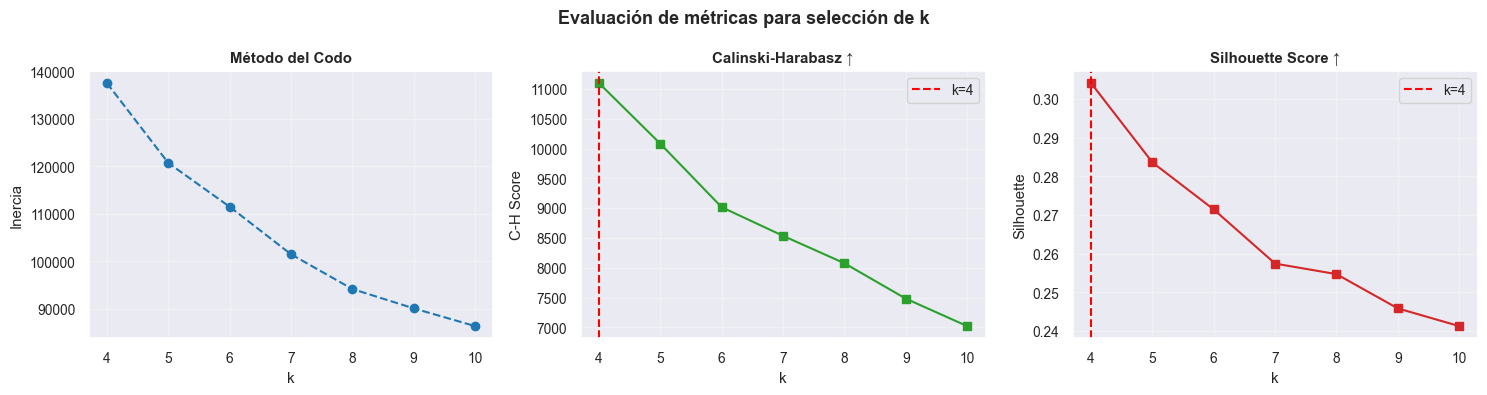

Calinski-Harabasz óptimo : k = 4
Silhouette óptimo        : k = 4


In [35]:
ks = list(rango_k)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Codo
axes[0].plot(ks, inercia, marker='o', color='tab:blue', linestyle='--')
axes[0].set_title('Método del Codo', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[0].grid(True, alpha=0.3)

# Calinski-Harabasz
k_ch = ks[ch_scores.index(max(ch_scores))]
axes[1].plot(ks, ch_scores, marker='s', color='tab:green')
axes[1].axvline(k_ch, color='red', ls='--', lw=1.5, label=f'k={k_ch}')
axes[1].set_title('Calinski-Harabasz ↑', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('C-H Score')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Silhouette
k_sil = ks[siluetas.index(max(siluetas))]
axes[2].plot(ks, siluetas, marker='s', color='tab:red')
axes[2].axvline(k_sil, color='red', ls='--', lw=1.5, label=f'k={k_sil}')
axes[2].set_title('Silhouette Score ↑', fontweight='bold')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Silhouette')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Evaluación de métricas para selección de k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("images/06_metricas_k.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Calinski-Harabasz óptimo : k = {k_ch}")
print(f"Silhouette óptimo        : k = {k_sil}")


---
## 7. Algoritmo de Agrupamiento: K-Means

Se seleccionó K-Means por su eficiencia computacional con datasets de gran tamaño
y su capacidad para encontrar agrupamientos globulares en el espacio PCA.

### 7.1. Justificación de k=5
Basado en las métricas anteriores y el conocimiento de dominio — el fútbol tiene
5 roles tácticos principales: Portero, Defensa, Mediocampista Defensivo,
Mediocampista/Extremo y Delantero — se selecciona **k=5**.


In [36]:
k_optimo = 5
kmeans_final = KMeans(n_clusters=k_optimo, random_state=random_seed, n_init='auto')
cluster_labels = kmeans_final.fit_predict(df_pca)

df['Cluster']     = cluster_labels
df_pca['Cluster'] = cluster_labels


### 7.2. Evaluación de Calidad del Clustering


In [37]:
print("\nTamaño de cada cluster (% del total):")
tamaños = df['Cluster'].value_counts(normalize=True).sort_index() * 100
print(tamaños)

silueta_final = silhouette_score(df_pca.drop(columns='Cluster').values, cluster_labels)
ch_final      = calinski_harabasz_score(df_pca.drop(columns='Cluster').values, cluster_labels)
print(f"\nSilhouette Score     : {silueta_final:.4f}")
print(f"Calinski-Harabasz    : {ch_final:,.2f}")



Tamaño de cada cluster (% del total):
Cluster
0    28.465578
1    10.752625
2    17.946324
3    22.695449
4    20.140023
Name: proportion, dtype: float64

Silhouette Score     : 0.2836
Calinski-Harabasz    : 10,080.22


In [38]:
# Scatter PCA coloreado por cluster
df_plot = pd.concat([df.reset_index(drop=True),
                     df_pca.drop(columns='Cluster').reset_index(drop=True)], axis=1)
df_plot['Cluster'] = cluster_labels

fig_pca = px.scatter(df_plot, x='PC1', y='PC2',
                     color=df_plot['Cluster'].astype(str),
                     hover_data=columnas,
                     title='PCA de jugadores por Cluster (PC1 vs PC2)',
                     opacity=0.70,
                     color_discrete_sequence=px.colors.qualitative.Set1)
fig_pca.add_vline(x=0, line_dash='dash', line_color='black')
fig_pca.add_hline(y=0, line_dash='dash', line_color='black')
fig_pca.update_layout(width=1000, height=700)
fig_pca.write_image("images/07_scatter_clusters.png", scale=2)
fig_pca.show()


---
## 8. Perfilamiento de Clusters


### 8.1. Kruskal-Wallis y Test de Dunn

**Kruskal-Wallis** (ANOVA no paramétrico) evalúa si existe al menos un cluster
que difiere significativamente de los demás en cada variable, sin asumir normalidad.

**Test de Dunn** (post-hoc) identifica específicamente qué pares de clusters
difieren entre sí, con corrección de Bonferroni para múltiples comparaciones.


In [40]:
df_perfil = df.copy()
df_perfil['Cluster'] = cluster_labels

kw_df, all_dunn = perfilamiento_clusters(df_perfil, columnas, k_optimo)


KRUSKAL-WALLIS
Variables significativas (p<0.05): 27 de 27



,Variable,H-statistic,p-value,Decisión
0,StandingTackle,13300.09,0.0,✅ Rechazar H0: Hay diferencias significativas ...
1,SlidingTackle,13162.44,0.0,✅ Rechazar H0: Hay diferencias significativas ...
2,Interceptions,12942.74,0.0,✅ Rechazar H0: Hay diferencias significativas ...
3,Finishing,12826.21,0.0,✅ Rechazar H0: Hay diferencias significativas ...
4,Marking,12511.96,0.0,✅ Rechazar H0: Hay diferencias significativas ...
...,...,...,...,...
22,SprintSpeed,6650.31,0.0,✅ Rechazar H0: Hay diferencias significativas ...
23,HeadingAccuracy,6133.85,0.0,✅ Rechazar H0: Hay diferencias significativas ...
24,Balance,5982.39,0.0,✅ Rechazar H0: Hay diferencias significativas ...
25,Strength,2629.24,0.0,✅ Rechazar H0: Hay diferencias significativas ...



TEST DE DUNN (Bonferroni) — solo variables significativas en KW


,Variable,Grupo 1,Grupo 2,p-value,Decisión
0,StandingTackle,0,1,0.0000,✅ Rechazar H0 — Hay diferencias significativas.
1,StandingTackle,0,2,0.0000,✅ Rechazar H0 — Hay diferencias significativas.
2,StandingTackle,0,3,0.0000,✅ Rechazar H0 — Hay diferencias significativas.
3,StandingTackle,0,4,0.0000,✅ Rechazar H0 — Hay diferencias significativas.
4,StandingTackle,1,2,0.0000,✅ Rechazar H0 — Hay diferencias significativas.
...,...,...,...,...,...
265,Jumping,1,3,0.0000,✅ Rechazar H0 — Hay diferencias significativas.
266,Jumping,1,4,0.0000,✅ Rechazar H0 — Hay diferencias significativas.
267,Jumping,2,3,0.0028,✅ Rechazar H0 — Hay diferencias significativas.
268,Jumping,2,4,0.0000,✅ Rechazar H0 — Hay diferencias significativas.



MEDIAS POR CLUSTER — top 15 variables más discriminantes


,StandingTackle,SlidingTackle,Interceptions,Finishing,Marking,Positioning,BallControl,Volleys,LongShots,Dribbling,ShortPassing,ShotPower,Vision,FKAccuracy,Crossing
Cluster,,,,,,,,,,,,,,,
0,67.5,65.1,66.4,50.1,64.8,58.7,68.2,48.6,57.7,65.1,69.3,64.9,62.2,52.8,62.2
1,14.1,14.0,17.0,12.0,15.1,11.2,19.9,12.3,12.6,13.8,27.3,22.5,37.0,14.4,14.2
2,35.6,32.1,36.9,67.9,37.8,69.8,72.2,63.6,66.4,72.3,68.4,70.9,66.7,59.3,63.5
3,64.3,62.2,60.9,29.9,61.3,37.2,53.0,30.6,32.8,46.3,55.6,45.8,41.3,33.2,43.0
4,31.2,30.0,29.0,56.4,33.6,56.9,60.7,48.4,51.6,60.9,57.0,58.7,53.3,42.1,48.5


### 8.3. Interpretación de Resultados

El test de Kruskal-Wallis confirma que todas las variables discriminan
significativamente entre clusters (p<0.05). Las variables con mayor poder
discriminante son `StandingTackle`, `SlidingTackle` e `Interceptions`,
lo que indica que la dimensión defensiva es el eje principal de diferenciación.

El test de Dunn confirma que todos los pares de clusters presentan diferencias
estadísticamente significativas (p<0.05, corrección Bonferroni).
La única comparación con p>0.001 es C2 vs C4 en `SlidingTackle` (p=0.001),
sugiriendo que estos dos clusters comparten un perfil defensivo similar en barridas.

### 8.4. Perfiles Identificados

| Cluster | Perfil Táctico | Fortalezas clave |
|---|---|---|
| **C0** | Mediocampista Defensivo (CDM) | Interceptions, Marking, StandingTackle, LongPassing |
| **C1** | Portero (GK) | Débil en todas las variables de campo — perfil no-campo |
| **C2** | Delantero / Atacante (ST/CF) | Finishing, Volleys, Positioning, LongShots |
| **C3** | Defensa Central (CB) | StandingTackle, SlidingTackle, Marking, Strength |
| **C4** | Extremo / Mediocampista Ofensivo (LW/RW/CAM) | Finishing, Acceleration, SprintSpeed, Positioning |


---
## 9. Conclusiones y Siguientes Pasos

### Pipeline

| Etapa | Decisión | Justificación |
|---|---|---|
| Selección de variables | 27 atributos puros | Excluye métricas compuestas y biométricas estáticas |
| Escalado | StandardScaler | PCA y K-Means son sensibles a la escala |
| Reducción dimensional | PCA (6 componentes, ≥88% varianza) | Elimina multicolinealidad, mejora clustering |
| Selección de k | Calinski-Harabasz + dominio | k=5 roles tácticos naturales en fútbol |
| Clustering | K-Means (`n_init='auto'`) | Eficiente y reproducible (semilla 333) |
| Perfilamiento | Z-scores + Kruskal-Wallis + Dunn | No paramétrico, confirma discriminación estadística |

### Conclusiones
- PCA seguido de K-Means permitió identificar 5 perfiles tácticos diferenciados
  a partir de 27 habilidades puras, sin depender de la posición nominal del jugador.
- Kruskal-Wallis y Test de Dunn confirman que los grupos son estadísticamente distintos.
- Los perfiles pueden usarse para armar equipos ficticios balanceados tácticamente.

